# FloaterHormann法

nodes: Nx x Ny =25 x 25 = 625, Chebyshev
d = (5, 5)
最大相対誤差:4.145202225159576e-05


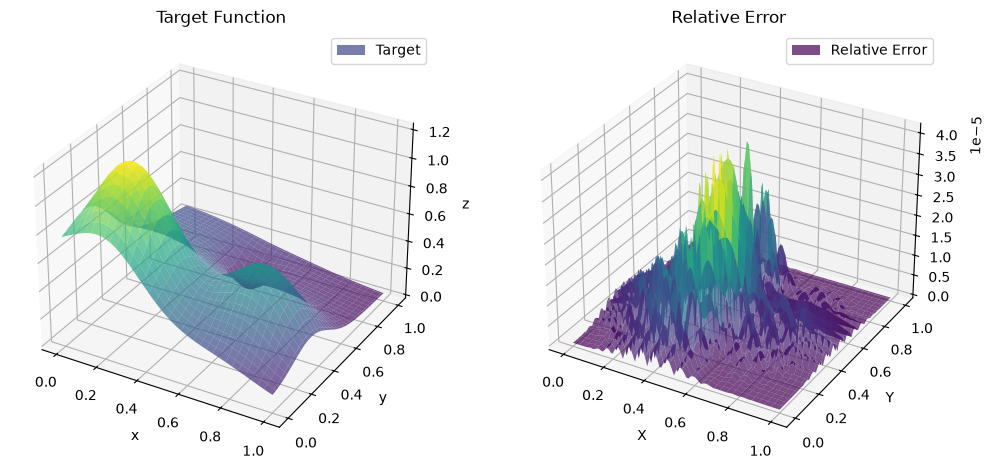

In [25]:
import numpy as np
from utils.fh import MultivariateFloaterHormannInterpolator
import matplotlib.pyplot as plt

##############################
# 関数を設定
##############################
def f(x,y): 
    """
    Domain:  [0,1] x [0,1]        
    Classical Franke's function
    """
    term1 = 0.75 * np.exp(-( (9*x - 2)**2 / 4 ) - ( (9*y - 2)**2 / 4 ))
    term2 = 0.75 * np.exp(-( (9*x + 1)**2 / 49 ) - ( (9*y + 1) / 10 ))
    term3 = 0.5  * np.exp(-( (9*x - 7)**2 / 4 ) - ( (9*y - 3)**2 / 4 ))
    term4 = -0.2 * np.exp(-( (9*x - 4)**2 ) - ( (9*y - 7)**2 ))
    
    return term1 + term2 + term3 + term4
x_bounds = [0.0,1.0] # 定義域の設定
x_min, x_max = x_bounds[0],x_bounds[1] # 範囲の端点
y_bounds = [0.0,1.0] # 定義域の設定
y_min, y_max = y_bounds[0],y_bounds[1] # 範囲の端点

# ==========================================
# 補間点の設定
# ==========================================
def get_nodes(a,b,n,is_chebyshev = True):
    """[a, b] 区間に n 個の補間点を生成する"""
    if is_chebyshev: # チェビシェフ点
        nodes = np.cos(np.pi * np.arange(n) / (n - 1))
        return np.sort(0.5 * (a + b) + 0.5 * (b - a) * nodes), "Chebyshev"
    else: # 等間隔点
        return np.linspace(a,b,n), "Equidistant"

Nx = Ny = 25
x_nodes, _ = get_nodes(x_min, x_max, Nx, is_chebyshev=True) 
y_nodes, _ = get_nodes(y_min, y_max, Ny, is_chebyshev=True) 
X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing='ij')# meshgridを作成
points = (x_nodes, y_nodes)
f_node_values = f(X_nodes,Y_nodes) 

# ==========================================
# 補間
# ==========================================
d = (5,5)
r = MultivariateFloaterHormannInterpolator(points, f_node_values, d)

#########################
# 誤差解析
#########################
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval) 
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval) # 真の値
r_eval = r((X_eval, Y_eval)) # 近似値(tupleで指定)
abs_err = np.abs(f_eval - r_eval)
max_abs_err = np.max(abs_err)
max_f_eval = np.max(f_eval)
rel_err = abs_err / max_f_eval
max_rel_err = max_abs_err / max_f_eval

print(f"nodes: Nx x Ny ={Nx} x {Ny} = {Nx * Ny}, {_}")
print(f"d = {d}")
print(f"最大相対誤差:{max_rel_err}")


# ==========================================
# 5. 3Dプロットによる可視化
# ==========================================
import matplotlib.pyplot as plt
from matplotlib import cm
fig = plt.figure(figsize=(12, 8))
ax1= fig.add_subplot(121, projection='3d')

# 補間された曲面を描画
surf_target = ax1.plot_surface(X_eval, Y_eval, f_eval, cmap=cm.viridis,
                        alpha=0.7, antialiased=True, label='Target')

ax1.set_title('Target Function')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# カラーバーの追加
# fig.colorbar(surf_target, ax=ax1, shrink=0.5, aspect=10)
ax1.legend()

ax2= fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_eval, Y_eval, rel_err, cmap="viridis",alpha=0.7, antialiased=True, label='Relative Error')
ax2.set_title('Relative Error')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()

plt.show()

In [26]:
import numpy as np
from utils.fh import MultivariateFloaterHormannInterpolator
import matplotlib.pyplot as plt
import time

def get_nodes(a,b,n,is_chebyshev = True):
    """[a, b] 区間に n 個の補間点を生成する"""
    if is_chebyshev: # チェビシェフ点
        nodes = np.cos(np.pi * np.arange(n) / (n - 1))
        return np.sort(0.5 * (a + b) + 0.5 * (b - a) * nodes), "Chebyshev"
    else: # 等間隔点
        return np.linspace(a,b,n), "Equidistant"

##############################
# 関数を設定
##############################
def f(x,y): 
    """
    Domain:  [0,1] x [0,1]        
    Classical Franke's function
    """
    term1 = 0.75 * np.exp(-( (9*x - 2)**2 / 4 ) - ( (9*y - 2)**2 / 4 ))
    term2 = 0.75 * np.exp(-( (9*x + 1)**2 / 49 ) - ( (9*y + 1) / 10 ))
    term3 = 0.5  * np.exp(-( (9*x - 7)**2 / 4 ) - ( (9*y - 3)**2 / 4 ))
    term4 = -0.2 * np.exp(-( (9*x - 4)**2 ) - ( (9*y - 7)**2 ))
    
    return term1 + term2 + term3 + term4
x_bounds = [0.0,1.0] # 定義域の設定
x_min, x_max = x_bounds[0],x_bounds[1] # 範囲の端点
y_bounds = [0.0,1.0] # 定義域の設定
y_min, y_max = y_bounds[0],y_bounds[1] # 範囲の端点

# ==========================================
# 実験設定
# ==========================================
target_err = 1e-4  # 目標とする最大相対誤差 (10^-4)

# テスト点（評価用）
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval)
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing="ij")
f_eval = f(X_eval, Y_eval)
max_f_eval = np.max(f_eval)

# 探索結果を保持する変数
best_result = None

# ==========================================
# パラメータグリッド探索 (N と d の全自動ループ)
# ==========================================
# Nを増やしながら試す
for N in range(5, 25):
    x_nodes, _ = get_nodes(x_min, x_max, N, is_chebyshev=True)
    y_nodes, _ = get_nodes(y_min, y_max, N, is_chebyshev=True)
    X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    f_node_values = f(X_nodes, Y_nodes)

    # d は 0 から N-1 まで試す
    for d_val in range(0, N):
        d = (d_val, d_val)

        try:
            # 1. モデル構築
            r = MultivariateFloaterHormannInterpolator(
                (x_nodes, y_nodes), f_node_values, d
            )

            # 2. 誤差の計算
            r_eval = r((X_eval, Y_eval))
            abs_err = np.abs(f_eval - r_eval)
            max_rel_err = np.max(abs_err) / max_f_eval

            # 3. 目標精度を達成したかチェック
            if max_rel_err <= target_err:
                # ----------------------------------------
                # 精度を達成したら「10万点代入時間」をプロファイリング
                # ----------------------------------------
                # 評価コスト測定用に大きな点数（例: 316x316 ≒ 10万点）を用意
                n_bench = 316
                X_b, Y_b = np.meshgrid(
                    np.linspace(x_min, x_max, n_bench),
                    np.linspace(y_min, y_max, n_bench),
                    indexing="ij",
                )

                # 実行時間を複数回測定して平均をとる
                times = []
                for _ in range(5):
                    start = time.perf_counter()
                    _ = r((X_b, Y_b))
                    end = time.perf_counter()
                    times.append(end - start)

                eval_time_ms = np.mean(times) * 1000  # ミリ秒換算

                best_result = {
                    "N": N,
                    "total_nodes": N * N,
                    "d": d,
                    "achieved_rel_err": max_rel_err,
                    "eval_time_ms": eval_time_ms,
                }
                break  # このNで達成できたらdのループを抜ける
        except Exception as e:
            continue

    if best_result is not None:
        break  # 最小のNで見つかったのでNのループも抜ける

# ==========================================
# 結果の出力
# ==========================================
if best_result:
    print(f"=== 【Floater-Hormann法】目標精度 {target_err} 達成結果 ===")
    print(
        f"必要節点数 (Nx x Ny) : {best_result['N']} x {best_result['N']} = {best_result['total_nodes']} 点"
    )
    print(f"最適パラメータ d     : {best_result['d']}")
    print(f"達成最大相対誤差    : {best_result['achieved_rel_err']:.3e}")
    print(
        f"10万点評価にかかる時間 : {best_result['eval_time_ms']:.2f} ms"
    )
else:
    print("指定した探索範囲では目標精度を達成できませんでした。")

=== 【Floater-Hormann法】目標精度 0.0001 達成結果 ===
必要節点数 (Nx x Ny) : 22 x 22 = 484 点
最適パラメータ d     : (12, 12)
達成最大相対誤差    : 9.857e-05
10万点評価にかかる時間 : 97.25 ms


nodes: Nx x Ny =22 x 22 = 484, Chebyshev
d = (12, 12)
最大相対誤差:9.85744854547983e-05


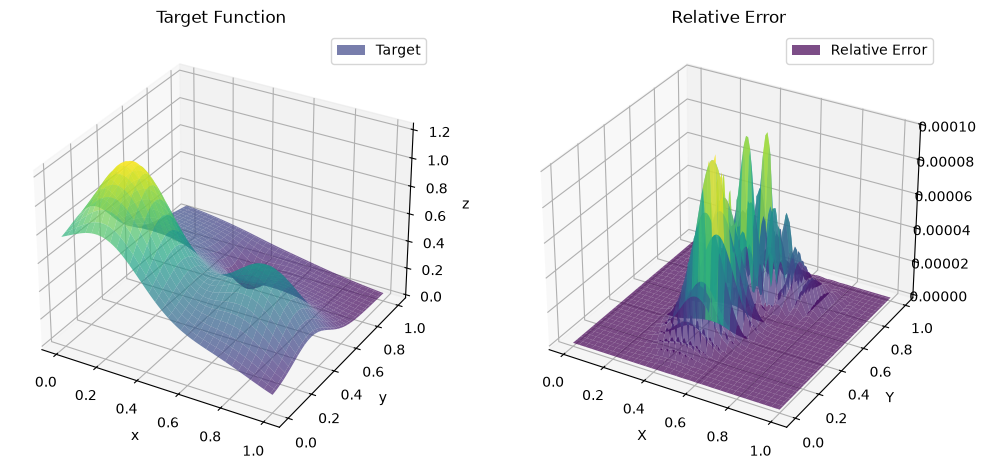

In [2]:
import numpy as np
from utils.fh import MultivariateFloaterHormannInterpolator
import matplotlib.pyplot as plt

##############################
# 関数を設定
##############################
def f(x,y): 
    """
    Domain:  [0,1] x [0,1]        
    Classical Franke's function
    """
    term1 = 0.75 * np.exp(-( (9*x - 2)**2 / 4 ) - ( (9*y - 2)**2 / 4 ))
    term2 = 0.75 * np.exp(-( (9*x + 1)**2 / 49 ) - ( (9*y + 1) / 10 ))
    term3 = 0.5  * np.exp(-( (9*x - 7)**2 / 4 ) - ( (9*y - 3)**2 / 4 ))
    term4 = -0.2 * np.exp(-( (9*x - 4)**2 ) - ( (9*y - 7)**2 ))
    
    return term1 + term2 + term3 + term4
x_bounds = [0.0,1.0] # 定義域の設定
x_min, x_max = x_bounds[0],x_bounds[1] # 範囲の端点
y_bounds = [0.0,1.0] # 定義域の設定
y_min, y_max = y_bounds[0],y_bounds[1] # 範囲の端点

# ==========================================
# 補間点の設定
# ==========================================
def get_nodes(a,b,n,is_chebyshev = True):
    """[a, b] 区間に n 個の補間点を生成する"""
    if is_chebyshev: # チェビシェフ点
        nodes = np.cos(np.pi * np.arange(n) / (n - 1))
        return np.sort(0.5 * (a + b) + 0.5 * (b - a) * nodes), "Chebyshev"
    else: # 等間隔点
        return np.linspace(a,b,n), "Equidistant"

Nx = Ny = 22
x_nodes, _ = get_nodes(x_min, x_max, Nx, is_chebyshev=True) 
y_nodes, _ = get_nodes(y_min, y_max, Ny, is_chebyshev=True) 
X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing='ij')# meshgridを作成
points = (x_nodes, y_nodes)
f_node_values = f(X_nodes,Y_nodes) 

# ==========================================
# 補間
# ==========================================
d = (12,12)
r = MultivariateFloaterHormannInterpolator(points, f_node_values, d)

#########################
# 誤差解析
#########################
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval) 
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval) # 真の値
r_eval = r((X_eval, Y_eval)) # 近似値(tupleで指定)
abs_err = np.abs(f_eval - r_eval)
max_abs_err = np.max(abs_err)
max_f_eval = np.max(f_eval)
rel_err = abs_err / max_f_eval
max_rel_err = max_abs_err / max_f_eval

print(f"nodes: Nx x Ny ={Nx} x {Ny} = {Nx * Ny}, {_}")
print(f"d = {d}")
print(f"最大相対誤差:{max_rel_err}")


# ==========================================
# 5. 3Dプロットによる可視化
# ==========================================
import matplotlib.pyplot as plt
from matplotlib import cm
fig = plt.figure(figsize=(12, 8))
ax1= fig.add_subplot(121, projection='3d')

# 補間された曲面を描画
surf_target = ax1.plot_surface(X_eval, Y_eval, f_eval, cmap=cm.viridis,
                        alpha=0.7, antialiased=True, label='Target')

ax1.set_title('Target Function')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# カラーバーの追加
# fig.colorbar(surf_target, ax=ax1, shrink=0.5, aspect=10)
ax1.legend()

ax2= fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_eval, Y_eval, rel_err, cmap="viridis",alpha=0.7, antialiased=True, label='Relative Error')
ax2.set_title('Relative Error')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()

plt.show()

# 3次スプライン補間

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import RectBivariateSpline


##############################
# 関数を設定
##############################
def f(x,y): 
    """
    Domain:  [0,1] x [0,1]        
    Classical Franke's function
    """
    term1 = 0.75 * np.exp(-( (9*x - 2)**2 / 4 ) - ( (9*y - 2)**2 / 4 ))
    term2 = 0.75 * np.exp(-( (9*x + 1)**2 / 49 ) - ( (9*y + 1) / 10 ))
    term3 = 0.5  * np.exp(-( (9*x - 7)**2 / 4 ) - ( (9*y - 3)**2 / 4 ))
    term4 = -0.2 * np.exp(-( (9*x - 4)**2 ) - ( (9*y - 7)**2 ))
    
    return term1 + term2 + term3 + term4
x_bounds = [0.0,1.0] # 定義域の設定
x_min, x_max = x_bounds[0],x_bounds[1] # 範囲の端点
y_bounds = [0.0,1.0] # 定義域の設定
y_min, y_max = y_bounds[0],y_bounds[1] # 範囲の端点

# ==========================================
# 実験設定
# ==========================================
target_err = 1e-4  # 目標とする最大相対誤差 (10^-4)

# テスト点（評価用）
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval)
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing="ij")
f_eval = f(X_eval, Y_eval)
max_f_eval = np.max(f_eval)


# ベンチマーク（代入時間測定）用：316x316 ≒ 10万点
n_bench = 316
x_b = np.linspace(x_min, x_max, n_bench)
y_b = np.linspace(y_min, y_max, n_bench)

# 探索結果を保持する変数
best_spline_result = None

# N を 5 から 100 まで増やして探索
for N in range(5, 101):
    x_nodes = np.linspace(x_min, x_max, N)
    y_nodes = np.linspace(y_min, y_max, N)
    X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    f_node_values = f(X_nodes, Y_nodes)

    try:
        # スプライン構築
        spline = RectBivariateSpline(x_nodes, y_nodes, f_node_values, kx=3, ky=3)

        # 評価（1次元配列を渡すと内部で網の目を作ってくれる）
        r_eval = spline(x_eval, y_eval)
        abs_err = np.abs(f_eval - r_eval)
        max_rel_err = np.max(abs_err) / max_f_eval

        if max_rel_err <= target_err:
            # 10万点での代入時間を計測
            times = []
            for _ in range(5):
                start = time.perf_counter()
                _ = spline(x_b, y_b)
                end = time.perf_counter()
                times.append(end - start)

            eval_time_ms = np.mean(times) * 1000

            best_spline_result = {
                "N": N,
                "total_nodes": N * N,
                "achieved_rel_err": max_rel_err,
                "eval_time_ms": eval_time_ms
            }
            break
    except Exception as e:
        continue

if best_spline_result:
    print(f"=== 【Bicubic Spline】目標精度 {target_err} 達成結果 ===")
    print(f"必要節点数 (Nx x Ny) : {best_spline_result['N']} x {best_spline_result['N']} = {best_spline_result['total_nodes']} 点")
    print(f"達成最大相対誤差    : {best_spline_result['achieved_rel_err']:.3e}")
    print(f"10万点評価にかかる時間 : {best_spline_result['eval_time_ms']:.2f} ms")
else:
    print("目標精度を達成できませんでした。")

=== 【Bicubic Spline】目標精度 0.0001 達成結果 ===
必要節点数 (Nx x Ny) : 31 x 31 = 961 点
達成最大相対誤差    : 9.784e-05
10万点評価にかかる時間 : 2.61 ms


# チェビシェフ多項式

In [29]:
import numpy as np
import time

##############################
# 関数を設定
##############################
def f(x,y): 
    """
    Domain:  [0,1] x [0,1]        
    Classical Franke's function
    """
    term1 = 0.75 * np.exp(-( (9*x - 2)**2 / 4 ) - ( (9*y - 2)**2 / 4 ))
    term2 = 0.75 * np.exp(-( (9*x + 1)**2 / 49 ) - ( (9*y + 1) / 10 ))
    term3 = 0.5  * np.exp(-( (9*x - 7)**2 / 4 ) - ( (9*y - 3)**2 / 4 ))
    term4 = -0.2 * np.exp(-( (9*x - 4)**2 ) - ( (9*y - 7)**2 ))
    
    return term1 + term2 + term3 + term4
x_bounds = [0.0,1.0] # 定義域の設定
x_min, x_max = x_bounds[0],x_bounds[1] # 範囲の端点
y_bounds = [0.0,1.0] # 定義域の設定
y_min, y_max = y_bounds[0],y_bounds[1] # 範囲の端点

# ==========================================
# 実験設定
# ==========================================
target_err = 1e-4  # 目標とする最大相対誤差 (10^-4)

# テスト点（評価用）
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval)
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing="ij")
f_eval = f(X_eval, Y_eval)
max_f_eval = np.max(f_eval)


# ベンチマーク（代入時間測定）用：316x316 ≒ 10万点
n_bench = 316
x_b = np.linspace(x_min, x_max, n_bench)
y_b = np.linspace(y_min, y_max, n_bench)
# ↓↓↓ この1行（X_b, Y_b の定義）を追加 ↓↓↓
X_b, Y_b = np.meshgrid(x_b, y_b, indexing="ij")
# ==========================================
# 2次元チェビシェフ多項式補間（修正版）
# ==========================================
# class Chebyshev2DInterpolator:
#     def __init__(self, x_bounds, y_bounds, N):
#         self.N = N
#         self.x_min, self.x_max = x_bounds
#         self.y_min, self.y_max = y_bounds
        
#         # 1次元チェビシェフ節点 (Type 1: ガウス点)
#         k = np.arange(N)
#         nodes_1d = np.cos((2 * k + 1) * np.pi / (2 * N))
        
#         # [a, b] への線形変換
#         self.x_nodes = 0.5 * (self.x_min + self.x_max) + 0.5 * (self.x_max - self.x_min) * nodes_1d
#         self.y_nodes = 0.5 * (self.y_min + self.y_max) + 0.5 * (self.y_max - self.y_min) * nodes_1d
        
#     def fit(self, func):
#         X_nodes, Y_nodes = np.meshgrid(self.x_nodes, self.y_nodes, indexing="ij")
#         F = func(X_nodes, Y_nodes)
        
#         # チェビシェフ変換行列 T_k(x_j)
#         k = np.arange(self.N)[:, None]
#         j = np.arange(self.N)[None, :]
#         T = np.cos((2 * j + 1) * k * np.pi / (2 * self.N))
        
#         # 重み係数
#         weights = np.ones(self.N)
#         weights[0] = 0.5
#         W = weights[:, None] * weights[None, :]
        
#         # 2次元チェビシェフ係数の計算
#         self.coeff = (2 / self.N)**2 * (T @ F @ T.T) * W

#     def evaluate(self, X_eval, Y_eval):
#         # [-1, 1] への正規化
#         x_norm = (2 * X_eval - (self.x_min + self.x_max)) / (self.x_max - self.x_min)
#         y_norm = (2 * Y_eval - (self.y_min + self.y_max)) / (self.y_max - self.y_min)
        
#         # 2次元配列の全要素に対してチェビシェフ多項式を評価
#         # T_k(x) : (N, H, W)
#         k = np.arange(self.N)[:, None, None]
#         T_x = np.cos(k * np.arccos(np.clip(x_norm, -1.0, 1.0)))
#         T_y = np.cos(k * np.arccos(np.clip(y_norm, -1.0, 1.0)))
        
#         # 補間値の計算: sum_{i,j} c_{i,j} * T_i(x) * T_j(y)
#         r_eval = np.zeros_like(X_eval)
#         for i in range(self.N):
#             for j in range(self.N):
#                 r_eval += self.coeff[i, j] * T_x[i] * T_y[j]
                
#         return r_eval
# ==========================================
# 2次元チェビシェフ多項式補間（行列積による高速化版）
# ==========================================
class Chebyshev2DInterpolator:
    def __init__(self, x_bounds, y_bounds, N):
        self.N = N
        self.x_min, self.x_max = x_bounds
        self.y_min, self.y_max = y_bounds
        
        k = np.arange(N)
        nodes_1d = np.cos((2 * k + 1) * np.pi / (2 * N))
        
        self.x_nodes = 0.5 * (self.x_min + self.x_max) + 0.5 * (self.x_max - self.x_min) * nodes_1d
        self.y_nodes = 0.5 * (self.y_min + self.y_max) + 0.5 * (self.y_max - self.y_min) * nodes_1d
        
    def fit(self, func):
        X_nodes, Y_nodes = np.meshgrid(self.x_nodes, self.y_nodes, indexing="ij")
        F = func(X_nodes, Y_nodes)
        
        k = np.arange(self.N)[:, None]
        j = np.arange(self.N)[None, :]
        T = np.cos((2 * j + 1) * k * np.pi / (2 * self.N))
        
        weights = np.ones(self.N)
        weights[0] = 0.5
        W = weights[:, None] * weights[None, :]
        
        self.coeff = (2 / self.N)**2 * (T @ F @ T.T) * W

    def evaluate(self, X_eval, Y_eval):
        # 評価点の元の形状を保存し、1次元に平坦化 (M,)
        target_shape = X_eval.shape
        x_flat = X_eval.ravel()
        y_flat = Y_eval.ravel()
        
        # [-1, 1] への正規化とクリッピング
        x_norm = (2 * x_flat - (self.x_min + self.x_max)) / (self.x_max - self.x_min)
        y_norm = (2 * y_flat - (self.y_min + self.y_max)) / (self.y_max - self.y_min)
        x_norm = np.clip(x_norm, -1.0, 1.0)
        y_norm = np.clip(y_norm, -1.0, 1.0)
        
        # 評価点数 M に対する arccos 計算: (M, 1)
        acos_x = np.arccos(x_norm)[:, None]
        acos_y = np.arccos(y_norm)[:, None]
        
        # 次数 k の配列: (1, N)
        k_row = np.arange(self.N)[None, :]
        
        # チェビシェフ基底行列 T_x, T_y の構築 -> 形状: (M, N)
        T_x = np.cos(acos_x * k_row)
        T_y = np.cos(acos_y * k_row)
        
        # === 高速化された行列演算 ===
        # 1. T_x (M, N) と coeff (N, N) の行列積 -> temp (M, N)
        temp = T_x @ self.coeff
        
        # 2. temp (M, N) と T_y (M, N) を要素ごとに掛け、行方向に和をとる -> (M,)
        r_flat = np.sum(temp * T_y, axis=1)
        
        return r_flat.reshape(target_shape)
# ==========================================
# 探索ループ
# ==========================================
best_cheby_result = None

for N in range(5, 51):
    try:
        cheby = Chebyshev2DInterpolator((x_min, x_max), (y_min, y_max), N)
        cheby.fit(f)

        r_eval = cheby.evaluate(X_eval, Y_eval)
        abs_err = np.abs(f_eval - r_eval)
        max_rel_err = np.max(abs_err) / max_f_eval

        if max_rel_err <= target_err:
            # 10万点代入時間計測
            times = []
            for _ in range(5):
                start = time.perf_counter()
                _ = cheby.evaluate(X_b, Y_b)
                end = time.perf_counter()
                times.append(end - start)

            eval_time_ms = np.mean(times) * 1000

            best_cheby_result = {
                "N": N,
                "total_nodes": N * N,
                "achieved_rel_err": max_rel_err,
                "eval_time_ms": eval_time_ms
            }
            break
    except Exception as e:
        print(f"Error at N={N}: {e}")
        continue

if best_cheby_result:
    print(f"=== 【2D Chebyshev Polynomial】目標精度 {target_err} 達成結果 ===")
    print(f"必要節点数 (Nx x Ny) : {best_cheby_result['N']} x {best_cheby_result['N']} = {best_cheby_result['total_nodes']} 点")
    print(f"達成最大相対誤差    : {best_cheby_result['achieved_rel_err']:.3e}")
    print(f"10万点評価にかかる時間 : {best_cheby_result['eval_time_ms']:.2f} ms")
else:
    print("目標精度を達成できませんでした。")

=== 【2D Chebyshev Polynomial】目標精度 0.0001 達成結果 ===
必要節点数 (Nx x Ny) : 24 x 24 = 576 点
達成最大相対誤差    : 8.605e-05
10万点評価にかかる時間 : 106.34 ms


# 面白くなかったので、一気にやりなおし

## ルンゲ関数 1e-4

In [30]:
import numpy as np
import time
from scipy.interpolate import RectBivariateSpline
from utils.fh import MultivariateFloaterHormannInterpolator
class Chebyshev2DInterpolator:
    def __init__(self, x_bounds, y_bounds, N):
        self.N = N
        self.x_min, self.x_max = x_bounds
        self.y_min, self.y_max = y_bounds
        
        k = np.arange(N)
        nodes_1d = np.cos((2 * k + 1) * np.pi / (2 * N))
        
        self.x_nodes = 0.5 * (self.x_min + self.x_max) + 0.5 * (self.x_max - self.x_min) * nodes_1d
        self.y_nodes = 0.5 * (self.y_min + self.y_max) + 0.5 * (self.y_max - self.y_min) * nodes_1d
        
    def fit(self, func):
        X_nodes, Y_nodes = np.meshgrid(self.x_nodes, self.y_nodes, indexing="ij")
        F = func(X_nodes, Y_nodes)
        
        k = np.arange(self.N)[:, None]
        j = np.arange(self.N)[None, :]
        T = np.cos((2 * j + 1) * k * np.pi / (2 * self.N))
        
        weights = np.ones(self.N)
        weights[0] = 0.5
        W = weights[:, None] * weights[None, :]
        
        self.coeff = (2 / self.N)**2 * (T @ F @ T.T) * W

    def evaluate(self, X_eval, Y_eval):
        # 評価点の元の形状を保存し、1次元に平坦化 (M,)
        target_shape = X_eval.shape
        x_flat = X_eval.ravel()
        y_flat = Y_eval.ravel()
        
        # [-1, 1] への正規化とクリッピング
        x_norm = (2 * x_flat - (self.x_min + self.x_max)) / (self.x_max - self.x_min)
        y_norm = (2 * y_flat - (self.y_min + self.y_max)) / (self.y_max - self.y_min)
        x_norm = np.clip(x_norm, -1.0, 1.0)
        y_norm = np.clip(y_norm, -1.0, 1.0)
        
        # 評価点数 M に対する arccos 計算: (M, 1)
        acos_x = np.arccos(x_norm)[:, None]
        acos_y = np.arccos(y_norm)[:, None]
        
        # 次数 k の配列: (1, N)
        k_row = np.arange(self.N)[None, :]
        
        # チェビシェフ基底行列 T_x, T_y の構築 -> 形状: (M, N)
        T_x = np.cos(acos_x * k_row)
        T_y = np.cos(acos_y * k_row)
        
        # === 高速化された行列演算 ===
        # 1. T_x (M, N) と coeff (N, N) の行列積 -> temp (M, N)
        temp = T_x @ self.coeff
        
        # 2. temp (M, N) と T_y (M, N) を要素ごとに掛け、行方向に和をとる -> (M,)
        r_flat = np.sum(temp * T_y, axis=1)
        
        return r_flat.reshape(target_shape)

# ==========================================
# 1. ターゲット関数の変更 (2次元ルンゲ型関数: alpha=100)
# ==========================================
def f(x, y):
    alpha = 100.0
    return 1.0 / (1.0 + alpha * ((x - 0.5)**2 + (y - 0.5)**2))

x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0
target_err = 1e-4  # 目標とする最大相対誤差 (10^-4)

# 評価点（テスト用）: 101x101
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval)
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing="ij")
f_eval = f(X_eval, Y_eval)
max_f_eval = np.max(np.abs(f_eval))

# 10万点代入時間測定用
n_bench = 316
x_b = np.linspace(x_min, x_max, n_bench)
y_b = np.linspace(y_min, y_max, n_bench)
X_b, Y_b = np.meshgrid(x_b, y_b, indexing="ij")


# ==========================================
# A. Floater-Hormann 法 (等間隔ノード)
# ==========================================
print("--- [1/3] Running Floater-Hormann (Equidistant) ---")
best_fh = None
for N in range(5, 51):
    # 等間隔ノードの生成
    x_nodes = np.linspace(x_min, x_max, N)
    y_nodes = np.linspace(y_min, y_max, N)
    X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    f_node_values = f(X_nodes, Y_nodes)

    for d_val in range(0, N):
        d = (d_val, d_val)
        try:
            r = MultivariateFloaterHormannInterpolator((x_nodes, y_nodes), f_node_values, d)
            r_eval = r((X_eval, Y_eval))
            max_rel_err = np.max(np.abs(f_eval - r_eval)) / max_f_eval

            if max_rel_err <= target_err:
                # 10万点時間計測
                times = [time.perf_counter() - (t:=time.perf_counter()) + (r((X_b, Y_b)) is not None)*0 for _ in range(5)]
                # 正確な時間測定
                t_list = []
                for _ in range(5):
                    s = time.perf_counter()
                    _ = r((X_b, Y_b))
                    t_list.append(time.perf_counter() - s)
                
                best_fh = {"N": N, "total_nodes": N*N, "d": d, "err": max_rel_err, "time_ms": np.min(t_list)*1000}
                break
        except Exception:
            continue
    if best_fh:
        break

if best_fh:
    print(f"FH法: N={best_fh['N']} (計 {best_fh['total_nodes']}点), d={best_fh['d']}, 誤差={best_fh['err']:.3e}, 時間={best_fh['time_ms']:.2f}ms")
else:
    print("FH法: 探索範囲内で達成不可")


# ==========================================
# B. Bicubic Spline (等間隔ノード)
# ==========================================
print("\n--- [2/3] Running Bicubic Spline (Equidistant) ---")
best_spline = None
for N in range(5, 151): # スプラインはNを大きめに探索
    x_nodes = np.linspace(x_min, x_max, N)
    y_nodes = np.linspace(y_min, y_max, N)
    X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    f_node_values = f(X_nodes, Y_nodes)

    try:
        spline = RectBivariateSpline(x_nodes, y_nodes, f_node_values, kx=3, ky=3)
        r_eval = spline(x_eval, y_eval)
        max_rel_err = np.max(np.abs(f_eval - r_eval)) / max_f_eval

        if max_rel_err <= target_err:
            t_list = []
            for _ in range(5):
                s = time.perf_counter()
                _ = spline(x_b, y_b)
                t_list.append(time.perf_counter() - s)
            best_spline = {"N": N, "total_nodes": N*N, "err": max_rel_err, "time_ms": np.min(t_list)*1000}
            break
    except Exception:
        continue

if best_spline:
    print(f"Spline: N={best_spline['N']} (計 {best_spline['total_nodes']}点), 誤差={best_spline['err']:.3e}, 時間={best_spline['time_ms']:.2f}ms")
else:
    print("Spline: 探索範囲(N<=150)で目標精度達成不可")


# ==========================================
# C. 2D Chebyshev Polynomial
# ==========================================
print("\n--- [3/3] Running Chebyshev Polynomial ---")
best_cheby = None
for N in range(5, 101):
    try:
        cheby = Chebyshev2DInterpolator((x_min, x_max), (y_min, y_max), N)
        cheby.fit(f)
        r_eval = cheby.evaluate(X_eval, Y_eval)
        max_rel_err = np.max(np.abs(f_eval - r_eval)) / max_f_eval

        if max_rel_err <= target_err:
            t_list = []
            for _ in range(5):
                s = time.perf_counter()
                _ = cheby.evaluate(X_b, Y_b)
                t_list.append(time.perf_counter() - s)
            best_cheby = {"N": N, "total_nodes": N*N, "err": max_rel_err, "time_ms": np.min(t_list)*1000}
            break
    except Exception:
        continue

if best_cheby:
    print(f"Chebyshev: N={best_cheby['N']} (計 {best_cheby['total_nodes']}点), 誤差={best_cheby['err']:.3e}, 時間={best_cheby['time_ms']:.2f}ms")
else:
    print("Chebyshev: 探索範囲(N<=100)で目標精度達成不可")

--- [1/3] Running Floater-Hormann (Equidistant) ---
FH法: N=31 (計 961点), d=(2, 2), 誤差=6.236e-05, 時間=119.46ms

--- [2/3] Running Bicubic Spline (Equidistant) ---
Spline: N=61 (計 3721点), 誤差=9.746e-05, 時間=1.77ms

--- [3/3] Running Chebyshev Polynomial ---
Chebyshev: N=47 (計 2209点), 誤差=8.196e-05, 時間=197.63ms


## ルンゲ関数 1e-8

In [32]:
import numpy as np
import time
from scipy.interpolate import RectBivariateSpline
from utils.fh import MultivariateFloaterHormannInterpolator
class Chebyshev2DInterpolator:
    def __init__(self, x_bounds, y_bounds, N):
        self.N = N
        self.x_min, self.x_max = x_bounds
        self.y_min, self.y_max = y_bounds
        
        k = np.arange(N)
        nodes_1d = np.cos((2 * k + 1) * np.pi / (2 * N))
        
        self.x_nodes = 0.5 * (self.x_min + self.x_max) + 0.5 * (self.x_max - self.x_min) * nodes_1d
        self.y_nodes = 0.5 * (self.y_min + self.y_max) + 0.5 * (self.y_max - self.y_min) * nodes_1d
        
    def fit(self, func):
        X_nodes, Y_nodes = np.meshgrid(self.x_nodes, self.y_nodes, indexing="ij")
        F = func(X_nodes, Y_nodes)
        
        k = np.arange(self.N)[:, None]
        j = np.arange(self.N)[None, :]
        T = np.cos((2 * j + 1) * k * np.pi / (2 * self.N))
        
        weights = np.ones(self.N)
        weights[0] = 0.5
        W = weights[:, None] * weights[None, :]
        
        self.coeff = (2 / self.N)**2 * (T @ F @ T.T) * W

    def evaluate(self, X_eval, Y_eval):
        # 評価点の元の形状を保存し、1次元に平坦化 (M,)
        target_shape = X_eval.shape
        x_flat = X_eval.ravel()
        y_flat = Y_eval.ravel()
        
        # [-1, 1] への正規化とクリッピング
        x_norm = (2 * x_flat - (self.x_min + self.x_max)) / (self.x_max - self.x_min)
        y_norm = (2 * y_flat - (self.y_min + self.y_max)) / (self.y_max - self.y_min)
        x_norm = np.clip(x_norm, -1.0, 1.0)
        y_norm = np.clip(y_norm, -1.0, 1.0)
        
        # 評価点数 M に対する arccos 計算: (M, 1)
        acos_x = np.arccos(x_norm)[:, None]
        acos_y = np.arccos(y_norm)[:, None]
        
        # 次数 k の配列: (1, N)
        k_row = np.arange(self.N)[None, :]
        
        # チェビシェフ基底行列 T_x, T_y の構築 -> 形状: (M, N)
        T_x = np.cos(acos_x * k_row)
        T_y = np.cos(acos_y * k_row)
        
        # === 高速化された行列演算 ===
        # 1. T_x (M, N) と coeff (N, N) の行列積 -> temp (M, N)
        temp = T_x @ self.coeff
        
        # 2. temp (M, N) と T_y (M, N) を要素ごとに掛け、行方向に和をとる -> (M,)
        r_flat = np.sum(temp * T_y, axis=1)
        
        return r_flat.reshape(target_shape)

# ==========================================
# 1. ターゲット関数の変更 (2次元ルンゲ型関数: alpha=100)
# ==========================================
def f(x, y):
    alpha = 100.0
    return 1.0 / (1.0 + alpha * ((x - 0.5)**2 + (y - 0.5)**2))

x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0
target_err = 1e-8  # 目標とする最大相対誤差 (10^-4)

# 評価点（テスト用）: 101x101
n_eval = 101
x_eval = np.linspace(x_min, x_max, n_eval)
y_eval = np.linspace(y_min, y_max, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing="ij")
f_eval = f(X_eval, Y_eval)
max_f_eval = np.max(np.abs(f_eval))

# 10万点代入時間測定用
n_bench = 316
x_b = np.linspace(x_min, x_max, n_bench)
y_b = np.linspace(y_min, y_max, n_bench)
X_b, Y_b = np.meshgrid(x_b, y_b, indexing="ij")


# ==========================================
# A. Floater-Hormann 法 (等間隔ノード)
# ==========================================
print("--- [1/3] Running Floater-Hormann (Equidistant) ---")
best_fh = None
for N in range(50, 100):
    # 等間隔ノードの生成
    x_nodes = np.linspace(x_min, x_max, N)
    y_nodes = np.linspace(y_min, y_max, N)
    X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    f_node_values = f(X_nodes, Y_nodes)

    for d_val in range(0, N):
        d = (d_val, d_val)
        try:
            r = MultivariateFloaterHormannInterpolator((x_nodes, y_nodes), f_node_values, d)
            r_eval = r((X_eval, Y_eval))
            max_rel_err = np.max(np.abs(f_eval - r_eval)) / max_f_eval

            if max_rel_err <= target_err:
                # 10万点時間計測
                times = [time.perf_counter() - (t:=time.perf_counter()) + (r((X_b, Y_b)) is not None)*0 for _ in range(5)]
                # 正確な時間測定
                t_list = []
                for _ in range(5):
                    s = time.perf_counter()
                    _ = r((X_b, Y_b))
                    t_list.append(time.perf_counter() - s)
                
                best_fh = {"N": N, "total_nodes": N*N, "d": d, "err": max_rel_err, "time_ms": np.min(t_list)*1000}
                break
        except Exception:
            continue
    if best_fh:
        break

if best_fh:
    print(f"FH法: N={best_fh['N']} (計 {best_fh['total_nodes']}点), d={best_fh['d']}, 誤差={best_fh['err']:.3e}, 時間={best_fh['time_ms']:.2f}ms")
else:
    print("FH法: 探索範囲内で達成不可")


# ==========================================
# B. Bicubic Spline (等間隔ノード)
# ==========================================
print("\n--- [2/3] Running Bicubic Spline (Equidistant) ---")
best_spline = None
for N in range(5, 151): # スプラインはNを大きめに探索
    x_nodes = np.linspace(x_min, x_max, N)
    y_nodes = np.linspace(y_min, y_max, N)
    X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    f_node_values = f(X_nodes, Y_nodes)

    try:
        spline = RectBivariateSpline(x_nodes, y_nodes, f_node_values, kx=3, ky=3)
        r_eval = spline(x_eval, y_eval)
        max_rel_err = np.max(np.abs(f_eval - r_eval)) / max_f_eval

        if max_rel_err <= target_err:
            t_list = []
            for _ in range(5):
                s = time.perf_counter()
                _ = spline(x_b, y_b)
                t_list.append(time.perf_counter() - s)
            best_spline = {"N": N, "total_nodes": N*N, "err": max_rel_err, "time_ms": np.min(t_list)*1000}
            break
    except Exception:
        continue

if best_spline:
    print(f"Spline: N={best_spline['N']} (計 {best_spline['total_nodes']}点), 誤差={best_spline['err']:.3e}, 時間={best_spline['time_ms']:.2f}ms")
else:
    print("Spline: 探索範囲(N<=150)で目標精度達成不可")


# ==========================================
# C. 2D Chebyshev Polynomial
# ==========================================
print("\n--- [3/3] Running Chebyshev Polynomial ---")
best_cheby = None
for N in range(5, 101):
    try:
        cheby = Chebyshev2DInterpolator((x_min, x_max), (y_min, y_max), N)
        cheby.fit(f)
        r_eval = cheby.evaluate(X_eval, Y_eval)
        max_rel_err = np.max(np.abs(f_eval - r_eval)) / max_f_eval

        if max_rel_err <= target_err:
            t_list = []
            for _ in range(5):
                s = time.perf_counter()
                _ = cheby.evaluate(X_b, Y_b)
                t_list.append(time.perf_counter() - s)
            best_cheby = {"N": N, "total_nodes": N*N, "err": max_rel_err, "time_ms": np.min(t_list)*1000}
            break
    except Exception:
        continue

if best_cheby:
    print(f"Chebyshev: N={best_cheby['N']} (計 {best_cheby['total_nodes']}点), 誤差={best_cheby['err']:.3e}, 時間={best_cheby['time_ms']:.2f}ms")
else:
    print("Chebyshev: 探索範囲(N<=100)で目標精度達成不可")

--- [1/3] Running Floater-Hormann (Equidistant) ---
FH法: N=64 (計 4096点), d=(4, 4), 誤差=9.771e-09, 時間=315.13ms

--- [2/3] Running Bicubic Spline (Equidistant) ---
Spline: N=101 (計 10201点), 誤差=5.551e-16, 時間=2.01ms

--- [3/3] Running Chebyshev Polynomial ---
Chebyshev: N=93 (計 8649点), 誤差=9.195e-09, 時間=638.76ms
